In [ ]:
import pandas as pd
import numpy as np
import joblib
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr

import matplotlib.pyplot as plt






In [ ]:
features = pd.read_csv("../data/customer_features.csv")
train = pd.read_csv("../data/customer_clv_train.csv")

df = train.merge(features, on="cust_id", how="left")

In [ ]:
# load churn models
#lgb_model = joblib.load("../models/churn_lgb_model.pkl")
#xgb_model = joblib.load("../models/churn_xgb_model.pkl")
churn_model = joblib.load("../models/churn_cat_model.pkl")
feature_cols = joblib.load("../models/feature_columns.pkl")

X = df[feature_cols]
p_return = churn_model.predict_proba(X)[:,1]

In [10]:
df_return = df[df["revenue_2018_2019"] > 0].copy()

X_rev = df_return[feature_cols]
y_rev = df_return["revenue_2018_2019"]

y_rev_log = np.log1p(y_rev)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_rev, y_rev_log, test_size=0.2, random_state=42
)

In [14]:
rev_model = lgb.LGBMRegressor(
    n_estimators=1200,
    learning_rate=0.03,
    num_leaves=64,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

rev_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002450 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4948
[LightGBM] [Info] Number of data points in the train set: 34126, number of used features: 30
[LightGBM] [Info] Start training from score 4.900821


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.03
,n_estimators,1200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,30


In [15]:
log_rev_pred = rev_model.predict(df[feature_cols])
rev_pred = np.expm1(log_rev_pred)

final_pred = p_return * rev_pred

In [ ]:
mae = mean_absolute_error(df["revenue_2018_2019"], final_pred)

print("MAE:", mae)

MAE: 66.91070683438589


In [22]:
corr,_ = spearmanr(df["revenue_2018_2019"], final_pred)

print("Spearman:", corr)

Spearman: 0.4235524664577908


In [18]:
# consider thresholds

for t in [0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9]:
    
    preds = np.where(
        p_return < t,
        0,
        p_return * rev_pred
    )
    
    mae = mean_absolute_error(df["revenue_2018_2019"], preds)
    
    print(t, mae)

0.1 66.90909145462449
0.15 66.76758310746693
0.2 65.16059510266496
0.25 61.89252231744912
0.3 59.76391870163005
0.35 58.79163992646083
0.4 58.189146032876906
0.45 57.82021742221213
0.5 57.55752442708703
0.55 57.58414816322839
0.6 58.00763227844035
0.65 58.809949152393465
0.7 59.836850338522076
0.75 61.00761459990015
0.8 62.415845730126335
0.85 64.11382112413746
0.9 66.26026221644194


# incorporate churn probability threshold

In [24]:
thresh_pred = np.where(
        p_return < 0.5,
        0,
        p_return * rev_pred
    )

In [28]:
mae_thresh = mean_absolute_error(df["revenue_2018_2019"], thresh_pred)

print("MAE:", mae_thresh)

corr_thresh,_ = spearmanr(df["revenue_2018_2019"], thresh_pred)

print("Spearman:", corr_thresh)

MAE: 57.55752442708703
Spearman: 0.4371509778427432


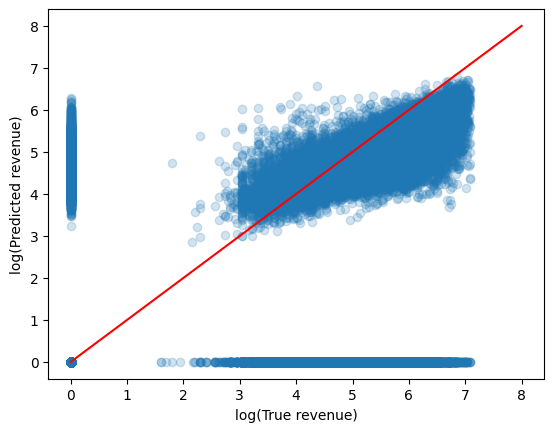

In [27]:
plt.scatter(
    np.log1p(df["revenue_2018_2019"]),
    np.log1p(thresh_pred),
    alpha=0.2
)

plt.xlabel("log(True revenue)")
plt.ylabel("log(Predicted revenue)")

plt.plot([0,8],[0,8],"r")

plt.show()

# Save Revenue Model

In [ ]:
joblib.dump(rev_model, "../models/rev_model.pkl")


['models/rev_model.pkl']